# CRAIG on Kaggle — Data-efficient Training of ResNet on CIFAR-10

Trains a ResNet on CIFAR-10 on Kaggle's free GPU using **CRAIG** — *Coresets for
Accelerating Incremental Gradient descent* (Mirzasoleiman, Bilmes & Leskovec, ICML 2020).
Paper: https://arxiv.org/pdf/1906.01827

Each epoch CRAIG greedily selects a small **weighted coreset** of the training set
(via facility-location maximisation) so you reach close to full-data accuracy while
back-propagating through only a fraction of the examples.

### Before you run
1. **Settings -> Accelerator -> GPU** (T4 x2 or P100).
2. **Settings -> Internet -> On** (needed to download CIFAR-10 and clone the repo).
3. If the GitHub repo is **private**: **Add-ons -> Secrets -> add `GITHUB_TOKEN`**
   (a GitHub Personal Access Token with `repo` scope). If the repo is public, skip this.

Then `Run All`.

## 1. Environment check

In [1]:
import sys, torch
print('Python :', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('CUDA   :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU    :', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU - set Settings -> Accelerator -> GPU')

Python : 3.12.13
PyTorch: 2.10.0+cu128
CUDA   : True
GPU    : Tesla T4


## 2. Get the code

Clones the repo into the Kaggle working directory. For a **private** repo, this uses the
`GITHUB_TOKEN` Kaggle secret; for a public repo no secret is needed.

In [2]:
import os, subprocess

REPO_USER = 'mainak9093'
REPO_NAME = 'Coreset-Analysis'
url = f'https://github.com/{REPO_USER}/{REPO_NAME}.git'

# Private repo -> use a Kaggle Secret named GITHUB_TOKEN (Add-ons -> Secrets).
try:
    from kaggle_secrets import UserSecretsClient
    _tok = UserSecretsClient().get_secret('GITHUB_TOKEN')
    url = f'https://{_tok}@github.com/{REPO_USER}/{REPO_NAME}.git'
    print('Using GITHUB_TOKEN secret for a private clone.')
except Exception:
    print('No GITHUB_TOKEN secret - assuming the repo is public.')

if not os.path.isdir(REPO_NAME):
    subprocess.run(['git', 'clone', '--depth', '1', url], check=True)  # token not echoed
%cd {REPO_NAME}
print('Files:', sorted(os.listdir('.')))

No GITHUB_TOKEN secret - assuming the repo is public.


Cloning into 'Coreset-Analysis'...


/kaggle/working/Coreset-Analysis
Files: ['.git', '.gitignore', 'GradualWarmupScheduler.py', 'README.md', 'README_BACKEND_AI.md', 'kaggle_train.ipynb', 'lazy_greedy.py', 'logistic.py', 'main.tex', 'mnist.py', 'requirements.txt', 'resnet.py', 'train_resnet.py', 'train_resnet_gpu.py', 'util.py', 'visualize_results.py']


## 3. Training configuration

| flag | meaning |
|------|---------|
| `SUBSET` | fraction kept as the coreset each round (`0.1` = 10%; `1.0` = full data) |
| `GREEDY` | CRAIG greedy facility-location selection (vs a random subset) |
| `EPOCHS` | total epochs - the LR schedule (milestones 100/150) targets ~200 for best accuracy |
| `LAG`    | re-select the coreset every `LAG` epochs (raise it to cut selection time) |
| `--smtk 0` | use the bundled **pure-Python** greedy (no external binary) - required on Kaggle |

**Expected (ResNet-20, CIFAR-10):** full data 200ep ~ 91-92%; CRAIG 10% greedy 200ep ~ 88-90%.

**Runtime:** 10% / 200 epochs is roughly 2-3 h on a T4. For a quick look set `EPOCHS = 60`,
or raise `LAG`, or use the full-data baseline cell.

In [3]:
ARCH    = 'resnet20'   # resnet20|32|44|56|110|1202
SUBSET  = 0.1          # coreset fraction; set 1.0 for the full-data baseline
EPOCHS  = 200          # lower (e.g. 60) for a quick run
BATCH   = 128
LAG     = 1            # re-select coreset every LAG epochs
WORKERS = 2
print(f'arch={ARCH} subset={SUBSET} epochs={EPOCHS} batch={BATCH} lag={LAG}')

arch=resnet20 subset=0.1 epochs=200 batch=128 lag=1


## 4. Train (CRAIG greedy coreset)

`-g` greedy selection, `-w` warm-start LR, `--smtk 0` pure-Python selection.
Results are written to `./results/` and checkpoints to `./checkpoints/`.

In [4]:
!python train_resnet_gpu.py -a {ARCH} -s {SUBSET} -g -w --smtk 0 -b {BATCH} --epochs {EPOCHS} --lag {LAG} --workers {WORKERS}

None
['resnet110', 'resnet1202', 'resnet20', 'resnet32', 'resnet44', 'resnet56']
✅ Using GPU: Tesla T4
   CUDA Version: 12.8
   GPU Memory: 15.64 GB
   GPU IDs: 0

--------- subset_size: 0.1, method: sgd, moment: 0.9, lr_schedule: mile, greedy: True, stoch: 0, rs: 1.0 ---------------

100%|████████████████████████████████████████| 170M/170M [00:12<00:00, 13.6MB/s]
�� lr schedule: mile, epochs: 200
�� lr: 0.1, b: 0.1
�� batch_size: 128, workers: 2

�� Random init subset size: 1.0% = 50000
�� Warm start learning rate
current lr 0.00000e+00
�� Selecting 5000 elements greedily from predictions
0
[   29    30    35 ... 49941 49992 49994]
5000
1
[    4     5    32 ... 49993 49998 49999]
5000
2
[    6    13    18 ... 49987 49991 49995]
5000
3
[    9    17    21 ... 49979 49982 49983]
5000
4
[    3    10    20 ... 49981 49984 49990]
5000
5
[   27    40    51 ... 49964 49980 49988]
5000
6
[    0    19    22 ... 49962 49966 49996]
5000
7
[    7    11    12 ... 49965 49978 49986]
5000
8
[    8   

**Full-data baseline** (no coreset) - uncomment to run instead:

In [5]:
# !python train_resnet_gpu.py -a {ARCH} -s 1.0 -w -b {BATCH} --epochs {EPOCHS} --workers {WORKERS}

## 5. Results

Loaded: results/cifar10_sgd_moment_0.9_resnet20_0.1_greedy_True_mile_lag_1.npz
Best test accuracy : 85.05%
Final test accuracy: 84.95%
Data coverage seen : 98.89% of the training set


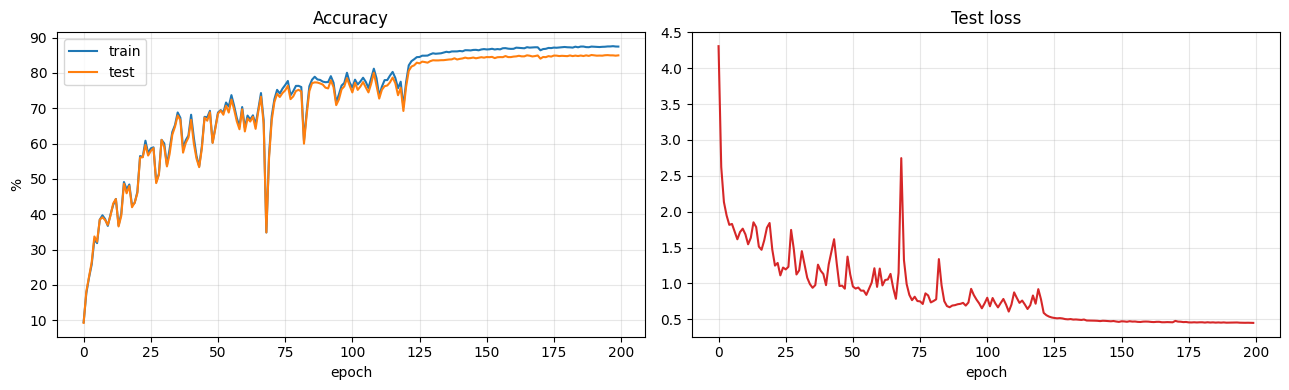

NameError: name 'model' is not defined

In [6]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt

files = glob.glob('results/*.npz')
assert files, 'No results in ./results - did training finish?'
latest = max(files, key=os.path.getctime)
print('Loaded:', latest)
d = np.load(latest)

test_acc  = d['test_acc']
train_acc = d['train_acc']
test_loss = d['test_loss']
not_sel   = d['not_selected']
ep = test_acc.shape[1]

print(f'Best test accuracy : {np.max(test_acc):.2f}%')
print(f'Final test accuracy: {test_acc[0, -1]:.2f}%')
print(f'Data coverage seen : {100 - not_sel[0, -1]:.2f}% of the training set')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(ep), train_acc[0], label='train')
ax[0].plot(range(ep), test_acc[0], label='test')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('%')
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(range(ep), test_loss[0], color='tab:red')
ax[1].set_title('Test loss'); ax[1].set_xlabel('epoch'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('results/summary.png', dpi=120); plt.show()
torch.save(model.state_dict(), 'results/my_model_weights.pth')